KMeans Clustering
===

In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn import datasets as skdatasets
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
import sys
from IPython.display import display, clear_output
import time

%matplotlib inline

#Plot the clustering
def plot_clusters(labels, clusters, X,i):
  
  unique_labels = set(labels)
  colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
  for k, col in zip(unique_labels, colors):
    class_member_mask = (labels == k)
    xy = X[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k', markersize=10, alpha=0.5)
    plt.plot(clusters[k,0],clusters[k,1],'o',markerfacecolor=col,
             markeredgecolor='k', markersize=20,alpha=0.8)
  plt.title('Clustering: Iteration %d'%(i))  



Generate Data
---

In [2]:
datasets={}

N = 100
X = np.vstack((2 * np.random.randn(N, 2) - 4, 
              (2 * np.random.randn(N, 2) + 4),
              (np.random.randn(N, 2) + np.array([[-6,4]]))
              ))
X = X[np.random.permutation(3*N),:]
datasets["BlobsSmall"] = X 

X, _ = skdatasets.make_blobs(n_samples=300, n_features=2, centers=10, cluster_std=1, random_state=589, )
datasets["BlobsLarge"] = X 

N = 100
X,_ = skdatasets.make_moons(n_samples=N, shuffle=True, noise=0.1, random_state=589)
datasets["Moons"] = 5*X 

N = 100
X, _ = skdatasets.make_circles(n_samples=N, shuffle=True, noise=0.08, random_state=589, factor=0.4)
datasets["Circles"] = 5*X


Run KMeans
---

In [3]:
n_clusters = 10      #Set Number of Clusters
L          = 100     # Number of learning steps
X          = datasets["Moons"] #Choose data set

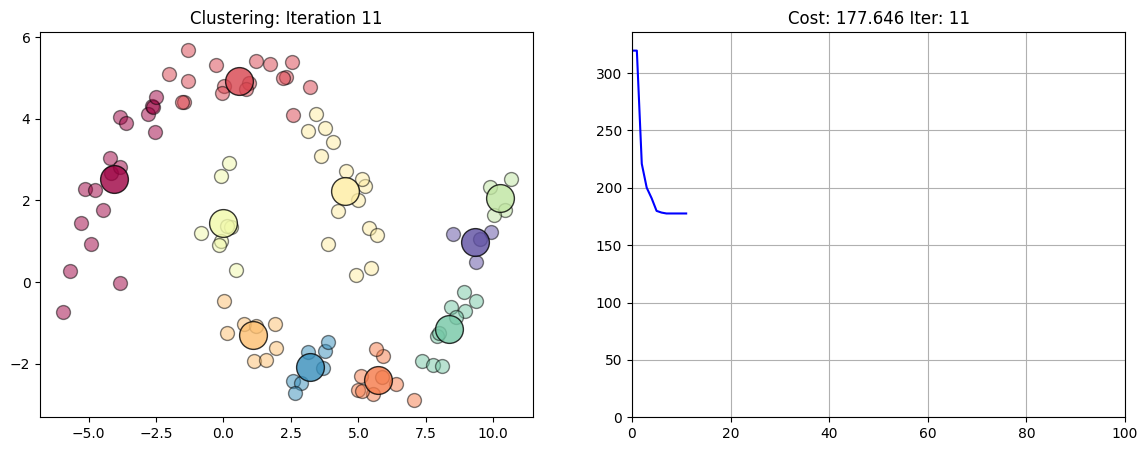

In [4]:
#Randomly Initialize the Clusters
cost = np.zeros(L) #Custering cost
centers = 2.5*(np.random.rand(n_clusters, 2)-0.5)
km = KMeans(n_clusters=n_clusters, n_init=1,init=centers,max_iter=1).fit(X)
km.cluster_centers_ =   centers

for i in range(L):

    labels = km.predict(X)
    centers = km.cluster_centers_
    cost[i] = km.inertia_
    
    km = KMeans(n_clusters=n_clusters, n_init=1,init=centers,max_iter=1).fit(X)
    
    clear_output(wait=True)
    plt.figure(101,figsize=(14,5))
    plt.subplot(1,2,1)
    plot_clusters(labels, centers, X,i)
      
    plt.subplot(1,2,2)
    plt.plot(cost[:i+1],'b-')
    plt.xlim(0,100)
    plt.ylim(0,1.05*max(cost[:i+1]))
    plt.title(f"Cost: {cost[i]:0.3f} Iter: %d"%(i))
    plt.grid(True)
    
    plt.show()
        
    if(i>10):
      if(np.abs(cost[i-1]-cost[i])<1e-6): break
    plt.pause(0.1)
